<a href="https://colab.research.google.com/github/moiz-shahid/Deep-Learning-Tutorials/blob/main/Tutorial-03-ANN-MNIST/DL_Tutorial_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values from 0-255 to 0-1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
baseline_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
baseline_model.compile(
    optimizer=Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [5]:
baseline_history = baseline_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9208 - loss: 0.2702 - val_accuracy: 0.9607 - val_loss: 0.1338
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9672 - loss: 0.1105 - val_accuracy: 0.9670 - val_loss: 0.1084
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9770 - loss: 0.0756 - val_accuracy: 0.9731 - val_loss: 0.0903
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9807 - loss: 0.0599 - val_accuracy: 0.9672 - val_loss: 0.1162
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9861 - loss: 0.0428 - val_accuracy: 0.9713 - val_loss: 0.1044
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9878 - loss: 0.0372 - val_accuracy: 0.9755 - val_loss: 0.0921
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9912 - loss: 0.0276 - val_accuracy: 0.9774 - val_loss: 0.0847
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9913 - loss: 0.0254 - 

In [6]:
baseline_loss, baseline_accuracy = baseline_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Baseline Test Loss:", baseline_loss)
print("Baseline Test Accuracy:", baseline_accuracy)

Baseline Test Loss: 0.08740507811307907
Baseline Test Accuracy: 0.9782000184059143


## Baseline Model Observation

The original neural network consisted of two hidden layers with 128 and 64 neurons using ReLU activation and the Adam optimizer.

The baseline model achieved a test accuracy of approximately **97.82%** with a test loss of **0.0874**.

During training, the training accuracy continued to increase and reached approximately 99%, while the validation accuracy remained around 97-98%. Similarly, the training loss continued to decrease while the validation loss stopped decreasing consistently.

This indicates that the original model performs well on MNIST, but it begins to show mild overfitting as training progresses.

# Task 1A — Different architectures

In [7]:
architectures = {
    "Original (128, 64)": [128, 64],
    "Small (64, 32)": [64, 32],
    "Large (256, 128)": [256, 128],
    "Deep (128, 64, 32)": [128, 64, 32]
}

In [8]:
architecture_results = {}

for name, layers in architectures.items():

    model = Sequential()
    model.add(Flatten(input_shape=(28, 28)))

    for neurons in layers:
        model.add(Dense(neurons, activation="relu"))

    model.add(Dense(10, activation="softmax"))

    model.compile(
        optimizer=Adam(),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    test_loss, test_accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    architecture_results[name] = {
        "accuracy": test_accuracy,
        "loss": test_loss,
        "history": history
    }

    print(name)
    print("Test Accuracy:", test_accuracy)
    print("Test Loss:", test_loss)
    print("-------------------------")

Original (128, 64)
Test Accuracy: 0.9761999845504761
Test Loss: 0.10274814814329147
-------------------------
Small (64, 32)
Test Accuracy: 0.9742000102996826
Test Loss: 0.09451187402009964
-------------------------
Large (256, 128)
Test Accuracy: 0.9772999882698059
Test Loss: 0.10662853717803955
-------------------------
Deep (128, 64, 32)
Test Accuracy: 0.9717000126838684
Test Loss: 0.12219750881195068
-------------------------


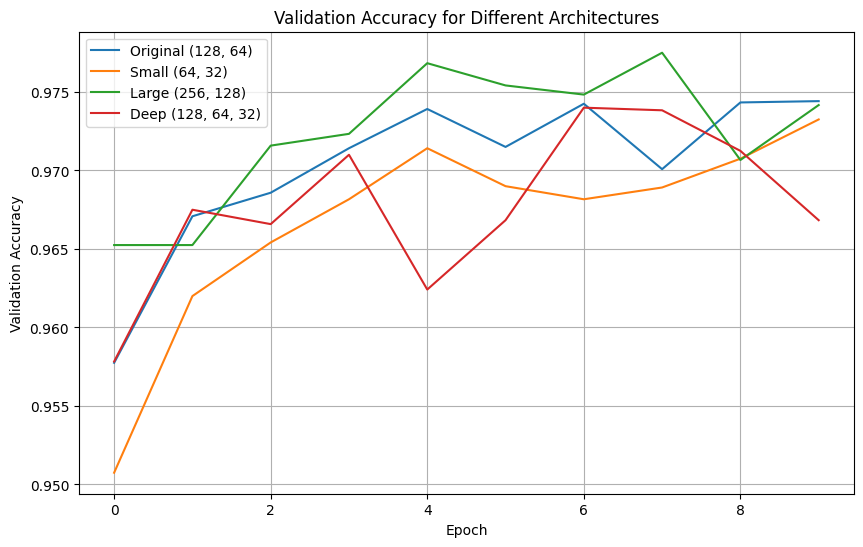

In [9]:
plt.figure(figsize=(10, 6))

for name, result in architecture_results.items():
    plt.plot(
        result["history"].history["val_accuracy"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy for Different Architectures")
plt.legend()
plt.grid()
plt.show()

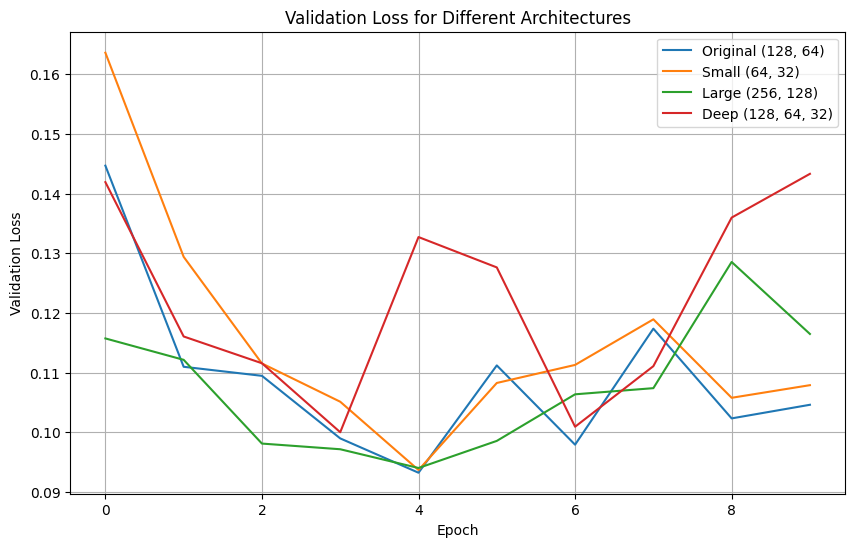

In [10]:
plt.figure(figsize=(10, 6))

for name, result in architecture_results.items():
    plt.plot(
        result["history"].history["val_loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss for Different Architectures")
plt.legend()
plt.grid()
plt.show()

## Task 1A: Effect of Different Network Architectures

Different neural network architectures were tested while keeping the optimizer, activation function, number of epochs, and other training parameters unchanged.

The large network `(256, 128)` achieved the highest test accuracy among the tested architectures at approximately **97.73%**.

The smaller `(64, 32)` network achieved approximately **97.42%**, showing that reducing the number of neurons slightly reduced performance.

The deeper `(128, 64, 32)` architecture achieved approximately **97.17%**, which was lower than the original and large models. Its validation curves also showed greater fluctuations.

Therefore, increasing the number of neurons provided a small improvement, but simply adding more hidden layers did not guarantee better performance. A more complex network can also become harder to optimize and may begin to fit the training data more strongly without improving generalization.

# Task 1B — Different activation functions

In [11]:
activations = [
    "relu",
    "tanh",
    "sigmoid"
]

activation_results = {}

for activation in activations:

    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation=activation),
        Dense(64, activation=activation),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    test_loss, test_accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    activation_results[activation] = {
        "accuracy": test_accuracy,
        "loss": test_loss,
        "history": history
    }

    print("Activation:", activation)
    print("Test Accuracy:", test_accuracy)
    print("Test Loss:", test_loss)
    print("-------------------------")

Activation: relu
Test Accuracy: 0.9735999703407288
Test Loss: 0.09248591959476471
-------------------------
Activation: tanh
Test Accuracy: 0.9706000089645386
Test Loss: 0.10595164448022842
-------------------------
Activation: sigmoid
Test Accuracy: 0.9750000238418579
Test Loss: 0.08220383524894714
-------------------------


## Task 1B: Effect of Activation Functions

The original architecture was also trained using ReLU, tanh, and sigmoid activation functions in the hidden layers.

The obtained test accuracies were approximately:

- ReLU: **97.36%**
- tanh: **97.06%**
- sigmoid: **97.50%**

In this experiment, sigmoid achieved the highest test accuracy and the lowest test loss. ReLU produced a very similar result, while tanh gave slightly lower accuracy.

This experiment shows that the choice of activation function can affect both convergence and final model performance. For this particular MNIST experiment and training setup, sigmoid gave the best final test result among the three tested activation functions.

# Task 2 — Compare Different Optimizers

In [12]:
optimizers = {
    "SGD": SGD(),
    "RMSprop": RMSprop(),
    "Adam": Adam()
}

optimizer_results = {}

for name, optimizer in optimizers.items():

    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    test_loss, test_accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    optimizer_results[name] = {
        "accuracy": test_accuracy,
        "loss": test_loss,
        "history": history
    }

    print(name)
    print("Test Accuracy:", test_accuracy)
    print("Test Loss:", test_loss)
    print("----------------------")

SGD
Test Accuracy: 0.9575999975204468
Test Loss: 0.1382019966840744
----------------------
RMSprop
Test Accuracy: 0.9771999716758728
Test Loss: 0.11386484652757645
----------------------
Adam
Test Accuracy: 0.9745000004768372
Test Loss: 0.09589511901140213
----------------------


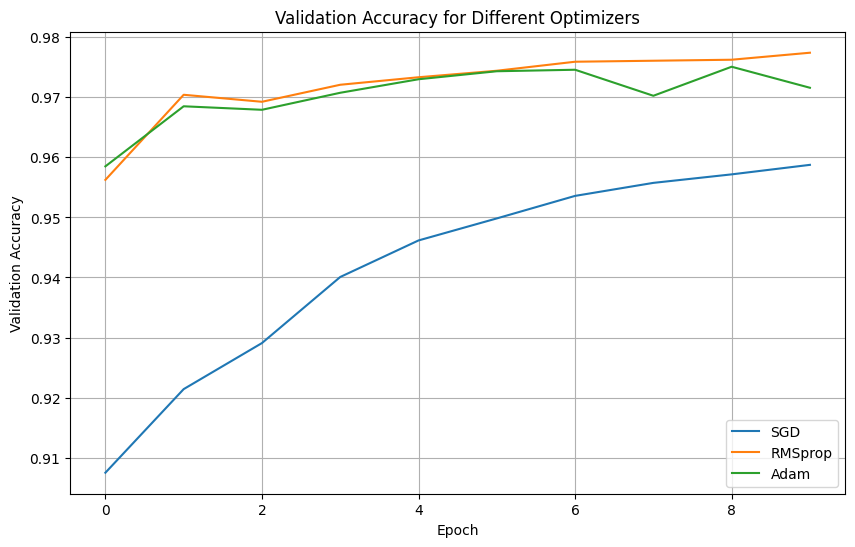

In [13]:
plt.figure(figsize=(10, 6))

for name, result in optimizer_results.items():
    plt.plot(
        result["history"].history["val_accuracy"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy for Different Optimizers")
plt.legend()
plt.grid()
plt.show()

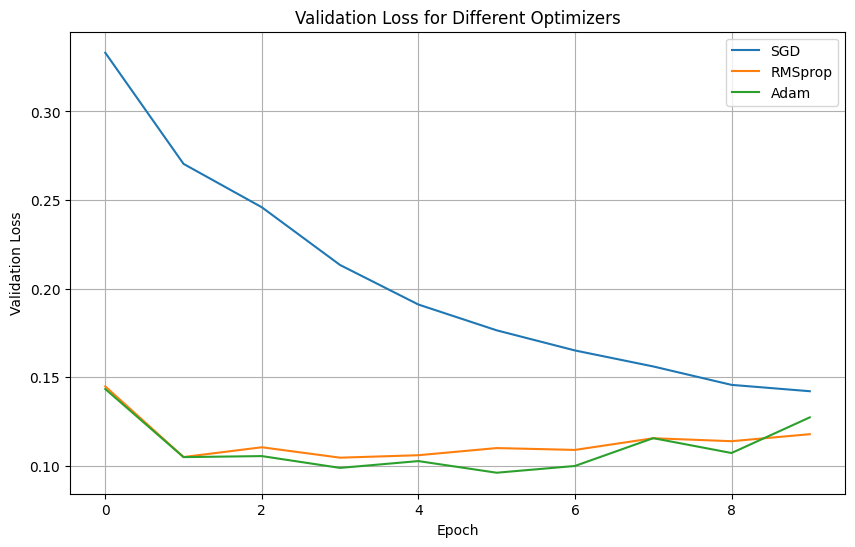

In [14]:
plt.figure(figsize=(10, 6))

for name, result in optimizer_results.items():
    plt.plot(
        result["history"].history["val_loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss for Different Optimizers")
plt.legend()
plt.grid()
plt.show()

In [27]:
import time

optimizer_times = {}

optimizer_classes = {
    "SGD": SGD,
    "RMSprop": RMSprop,
    "Adam": Adam
}

for name, optimizer_class in optimizer_classes.items():

    # Create a fresh model
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(10, activation="softmax")
    ])

    # Create a fresh optimizer instance
    optimizer = optimizer_class()

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    end_time = time.time()

    training_time = end_time - start_time

    optimizer_times[name] = training_time

    print(
        name,
        "Training Time:",
        round(training_time, 2),
        "seconds"
    )

SGD Training Time: 48.81 seconds
RMSprop Training Time: 65.19 seconds
Adam Training Time: 64.5 seconds


## Task 2: Comparison of Different Optimizers

Three optimizers, SGD, RMSprop, and Adam, were compared using the same neural network architecture, batch size, and number of epochs.

The obtained results were:

| Optimizer | Test Accuracy | Training Time |
|---|---:|---:|
| SGD | 95.76% | 48.81 s |
| RMSprop | 97.72% | 65.19 s |
| Adam | 97.45% | 64.50 s |

### Observation

SGD required the least wall-clock training time, completing 10 epochs in approximately 48.81 seconds. However, its learning curves showed slower convergence, and it achieved the lowest test accuracy of approximately 95.76%.

RMSprop required approximately 65.19 seconds and achieved the highest test accuracy of approximately 97.72%. Its validation accuracy increased rapidly during the early epochs, showing faster convergence in terms of model performance.

Adam required approximately 64.50 seconds and achieved approximately 97.45% test accuracy. Like RMSprop, Adam converged much faster than SGD in terms of accuracy and loss reduction.

Therefore, SGD was computationally faster for the fixed 10-epoch experiment, but it learned more slowly and produced lower final accuracy. RMSprop and Adam required slightly more training time but achieved substantially better model performance.

### Conclusion

Among the tested optimizers, **RMSprop provided the best final accuracy**, while **SGD had the shortest wall-clock training time**. Adam provided a good balance between training time, convergence behavior, and accuracy.

# Task 3A — Overfitting and Underfitting

In [15]:
overfit_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

overfit_model.compile(
    optimizer=Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

overfit_history = overfit_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9217 - loss: 0.2648 - val_accuracy: 0.9573 - val_loss: 0.1460
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9669 - loss: 0.1103 - val_accuracy: 0.9653 - val_loss: 0.1129
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9770 - loss: 0.0745 - val_accuracy: 0.9712 - val_loss: 0.0998
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9819 - loss: 0.0572 - val_accuracy: 0.9719 - val_loss: 0.0975
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9857 - loss: 0.0439 - val_accuracy: 0.9695 - val_loss: 0.1114
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9887 - loss: 0.0350 - val_accuracy: 0.9722 - val_loss: 0.1047
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9900 - loss: 0.0296 - val_accuracy: 0.9741 - val_loss: 0.1039
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9915 - loss: 0.0258 - 

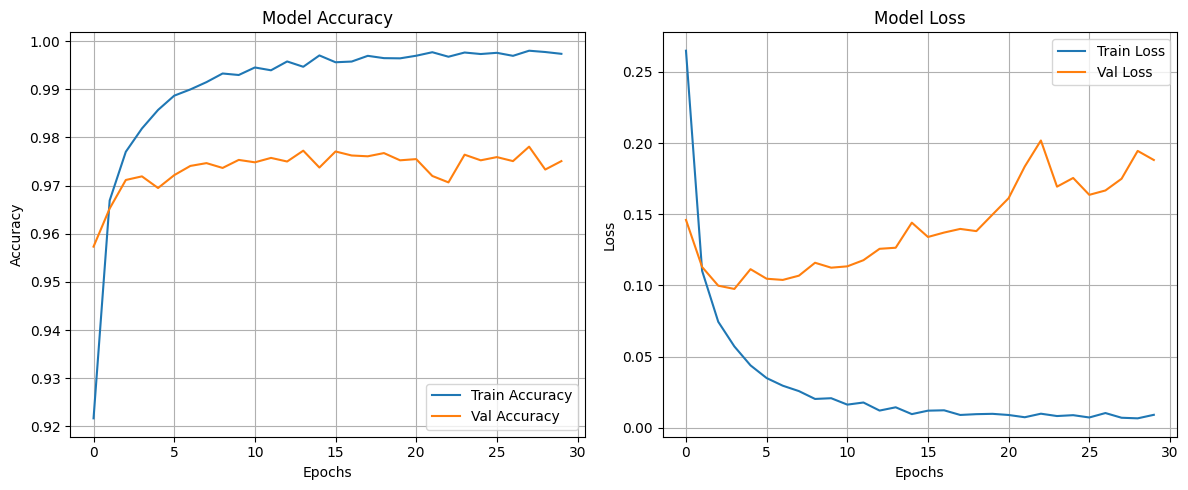

In [16]:
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)

plt.plot(
    overfit_history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    overfit_history.history["val_accuracy"],
    label="Val Accuracy"
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.grid()


# Loss
plt.subplot(1, 2, 2)

plt.plot(
    overfit_history.history["loss"],
    label="Train Loss"
)

plt.plot(
    overfit_history.history["val_loss"],
    label="Val Loss"
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Task 3A: Overfitting and Effect of Increasing Epochs

To observe the effect of increasing the number of epochs, the original neural network was trained for 30 epochs.

The training curves clearly show overfitting.

Training accuracy continued increasing and approached approximately **99.8%**, while validation accuracy remained around **97-98%** and showed only small fluctuations.

The effect is even clearer in the loss curves. Training loss continuously decreased and approached zero. However, validation loss initially decreased and then started increasing after the first few epochs.

This means that the model continued learning the training data but its ability to generalize to validation data stopped improving.

Therefore, increasing the number of epochs too much caused the model to overfit the training dataset.

# Task 3B — Implement Early Stopping

In [17]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [18]:
early_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

early_model.compile(
    optimizer=Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_history = early_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9225 - loss: 0.2617 - val_accuracy: 0.9632 - val_loss: 0.1272
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9672 - loss: 0.1087 - val_accuracy: 0.9703 - val_loss: 0.1028
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9771 - loss: 0.0757 - val_accuracy: 0.9699 - val_loss: 0.1019
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9821 - loss: 0.0559 - val_accuracy: 0.9746 - val_loss: 0.0900
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9863 - loss: 0.0427 - val_accuracy: 0.9743 - val_loss: 0.0891
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9877 - loss: 0.0370 - val_accuracy: 0.9732 - val_loss: 0.0967
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9912 - loss: 0.0267 - val_accuracy: 0.9753 - val_loss: 0.1014
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9923 - loss: 0.0239 - 

In [19]:
print(
    "Training stopped after:",
    len(early_history.history["loss"]),
    "epochs"
)

Training stopped after: 8 epochs


## Task 3B: Early Stopping

Early Stopping was implemented by monitoring the validation loss with a patience value of 3.

Although the maximum number of epochs was set to 30, training automatically stopped after **8 epochs**.

The best validation loss was obtained around epoch 5. After this point, validation loss did not improve for three consecutive epochs, so Early Stopping terminated the training process.

Since `restore_best_weights=True` was used, the model restored the weights corresponding to the best validation loss rather than keeping the weights from the final epoch.

Early Stopping therefore prevents unnecessary training and helps reduce overfitting by stopping before validation performance begins to degrade significantly.

# Task 3C — Regularization

In [20]:
regularized_model = Sequential([
    Flatten(input_shape=(28, 28)),

    Dense(128, activation="relu"),
    Dropout(0.2),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(10, activation="softmax")
])

In [21]:
regularized_model.compile(
    optimizer=Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [23]:
regularized_history = regularized_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8901 - loss: 0.3700 - val_accuracy: 0.9579 - val_loss: 0.1417
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9480 - loss: 0.1716 - val_accuracy: 0.9663 - val_loss: 0.1110
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9599 - loss: 0.1343 - val_accuracy: 0.9697 - val_loss: 0.1051
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9668 - loss: 0.1102 - val_accuracy: 0.9707 - val_loss: 0.0962
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9710 - loss: 0.0946 - val_accuracy: 0.9752 - val_loss: 0.0862
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9728 - loss: 0.0862 - val_accuracy: 0.9742 - val_loss: 0.0887
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9759 - loss: 0.0772 - val_accuracy: 0.9777 - val_loss: 0.0805
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9777 - loss: 0.0708 - 

In [24]:
test_loss, test_accuracy = regularized_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Improved Model Test Loss:", test_loss)
print("Improved Model Test Accuracy:", test_accuracy)
print(
    "Number of epochs:",
    len(regularized_history.history["loss"])
)

Improved Model Test Loss: 0.07068858295679092
Improved Model Test Accuracy: 0.9793999791145325
Number of epochs: 10


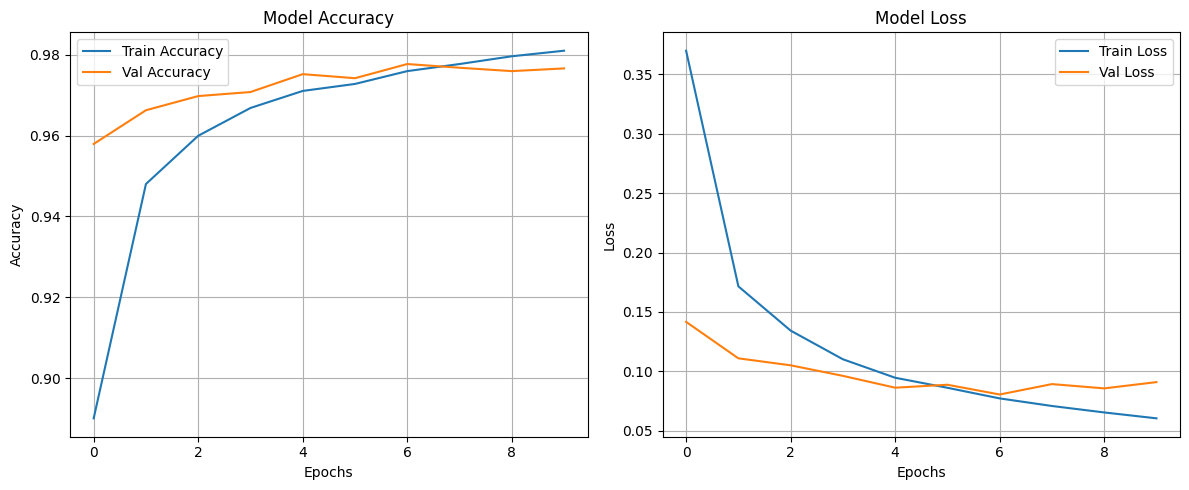

In [25]:
plt.figure(figsize=(12, 5))

# Accuracy graph
plt.subplot(1, 2, 1)

plt.plot(
    regularized_history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    regularized_history.history["val_accuracy"],
    label="Val Accuracy"
)

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()


# Loss graph
plt.subplot(1, 2, 2)

plt.plot(
    regularized_history.history["loss"],
    label="Train Loss"
)

plt.plot(
    regularized_history.history["val_loss"],
    label="Val Loss"
)

plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Task 3C: Regularization and Final Improved Model

To reduce overfitting, Dropout regularization was added after both hidden layers. A dropout rate of 0.2 means that 20% of the neurons are randomly disabled during each training update, which prevents the network from relying too strongly on individual neurons.

Early Stopping was also used together with Dropout to stop training when validation loss stopped improving.

The improved model achieved:

- **Test Accuracy: approximately 97.94%**
- **Test Loss: approximately 0.0707**
- **Training stopped after 10 epochs**

Compared with the baseline model:

- Baseline Test Accuracy: approximately **97.82%**
- Baseline Test Loss: approximately **0.0874**

The improved model therefore achieved slightly higher test accuracy and a lower test loss.

The final accuracy graph shows that the training and validation accuracy curves remain relatively close compared with the deliberately overfitted model. Similarly, both training and validation loss initially decrease together.

A small increase in validation loss can be observed during the later epochs, indicating the beginning of mild overfitting. However, Early Stopping detects this behavior and restores the model weights from the epoch with the best validation loss.

Therefore, the combination of Dropout regularization and Early Stopping reduced overfitting and produced a better-generalized model. The final curves are reasonably close to the desired well-fitted behavior shown in the tutorial.

## Analysis of the Improved Model

The final model shows a much better balance between training and validation performance.

The training and validation accuracy curves remain close to each other throughout training. By the final epochs, training accuracy is approximately 98%, while validation accuracy remains around 97–98%. The small gap between the two curves indicates that the model generalizes well to unseen validation data.

Both training and validation loss decrease significantly during the initial epochs. Training loss continues to decrease throughout training, while validation loss reaches its minimum and then shows a small increase during the later epochs. This indicates the beginning of mild overfitting.

However, the difference between the training and validation curves remains relatively small compared with the deliberately overfitted model. Early Stopping and Dropout regularization help control this overfitting and improve generalization.

The final curves are close to the desired behavior shown in the tutorial, where training and validation accuracy remain close and both losses decrease to relatively low values.

Therefore, the improved model can be considered reasonably well-fitted, with only mild overfitting appearing during the final epochs.